# 📘 CIFAR-10 Image Classification: ANN vs CNN – A Complete Learning Journey

**Student:** K Md Yasir Waqas  
**Project:** CELEBAL Internship Assignment -4 – Deep Learning Pipeline on CIFAR-10  
**Objective:** Build an image classification model on CIFAR-10.
Build an image classification model on CIFAR-10 and analyze performance across architectures and training strategies. (Do it with both ANN & CNN)

# Executive Summary
This study investigates the impact of neural network architecture and training strategies on CIFAR-10 image classification.
A total of seven model variants were implemented and evaluated, including a baseline ANN, deeper ANN, baseline CNN, scaled CNN, extended training, EarlyStopping, and data augmentation.
The best-performing model was the Scaled CNN architecture, achieving a test accuracy of 71.01%.
The results demonstrate that convolutional neural networks significantly outperform fully connected neural networks on image classification tasks because they preserve spatial information and learn hierarchical visual features.
In addition to comparing ANN and CNN architectures, this study evaluates the effect of increased model capacity, longer training schedules, regularization techniques, and data augmentation strategies.

---


## 1. Setup & Imports

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# For reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load & Explore CIFAR-10

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(f"Training data shape: {x_train.shape}, dtype: {x_train.dtype}")
print(f"Test data shape:     {x_test.shape}")
print(f"Label shape:         {y_train.shape}, unique classes: {len(np.unique(y_train))}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8466s 50us/step
Training data shape: (50000, 32, 32, 3), dtype: uint8
Test data shape:     (10000, 32, 32, 3)
Label shape:         (50000, 1), unique classes: 10


### Visualise a few samples

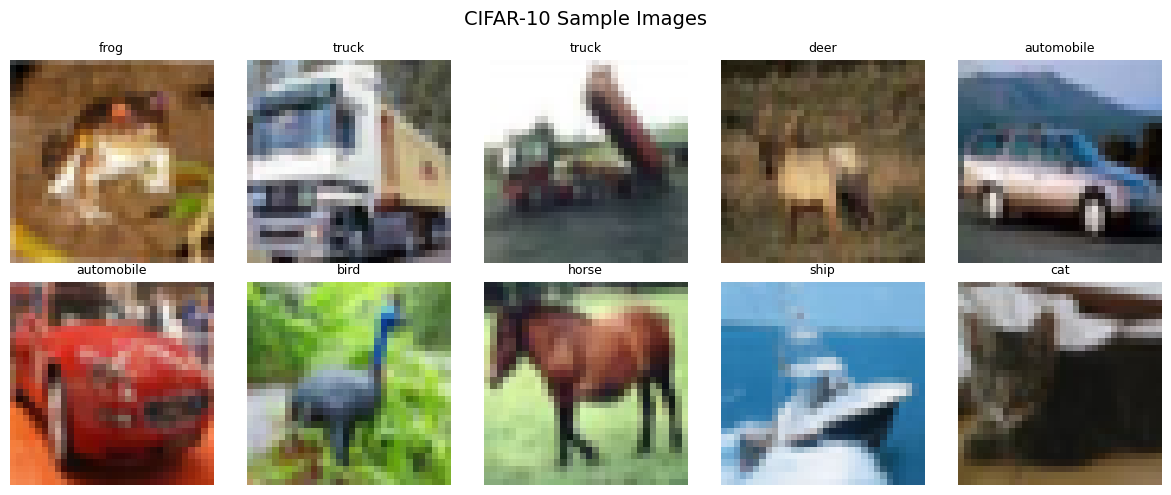

In [4]:
plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=9)
    plt.axis('off')
plt.suptitle("CIFAR-10 Sample Images", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Preprocessing

- Normalising pixel values to [0, 1] for stable gradient updates is more preferred
- Flatten images for the ANN (3072‑dimensional vectors).
- Keeping the 4D shape for CNNs.

In [5]:
# Normalise
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

# Flatten for ANN
x_train_flat = x_train_norm.reshape(x_train_norm.shape[0], -1)
x_test_flat  = x_test_norm.reshape(x_test_norm.shape[0], -1)

print("Flattened training shape:", x_train_flat.shape)   # (50000, 3072)

Flattened training shape: (50000, 3072)


# Baseline ANN

###Observation
The baseline ANN achieved a test accuracy of 41.77%. Although the model contains more than 1.7 million trainable parameters, it processes images as flattened vectors and therefore loses spatial information present in the original image. As a result, the ANN struggles to learn meaningful visual patterns and performs substantially worse than CNN-based architectures.

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,   # 10% of training → validation
    batch_size=64,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.2693 - loss: 1.9884 - val_accuracy: 0.3382 - val_loss: 1.8336
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 30ms/step - accuracy: 0.3201 - loss: 1.8511 - val_accuracy: 0.3546 - val_loss: 1.7814
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3453 - loss: 1.7973 - val_accuracy: 0.3610 - val_loss: 1.7565
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3540 - loss: 1.7725 - val_accuracy: 0.3974 - val_loss: 1.7132
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3667 - loss: 1.7333 - val_accuracy: 0.4064 - val_loss: 1.6719
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3725 - loss: 1.7162 - val_accuracy: 0.3818 - val_loss: 1.7035
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3797 - loss: 1.7013 - val_accuracy: 0.4000 - val_loss: 1.6789
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3866 - loss: 1.6855 - 

In [8]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"🔹 ANN Test Accuracy: {ann_test_acc:.4f}")

🔹 ANN Test Accuracy: 0.4177


## Baseline CNN
CNNs preserve the image grid. Convolutions learn local features, pooling reduces dimensions, and dense layers classify. BatchNorm and dropout fight overfitting.

In [9]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,194 (1.36 MB)

 Trainable params: 357,002 (1.36 MB)

 Non-trainable params: 192 (768.00 B)

In [10]:
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 120ms/step - accuracy: 0.4643 - loss: 1.5069 - val_accuracy: 0.5900 - val_loss: 1.1915
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 124ms/step - accuracy: 0.5990 - loss: 1.1429 - val_accuracy: 0.6580 - val_loss: 0.9859
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 122ms/step - accuracy: 0.6665 - loss: 0.9578 - val_accuracy: 0.6530 - val_loss: 1.0365
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.7113 - loss: 0.8298 - val_accuracy: 0.5624 - val_loss: 1.5028
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 126ms/step - accuracy: 0.7459 - loss: 0.7243 - val_accuracy: 0.6738 - val_loss: 0.9726
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 122ms/step - accuracy: 0.7711 - loss: 0.6520 - val_accuracy: 0.6586 - val_loss: 1.0103
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.7921 - loss: 0.5853 - val_accuracy: 0.6580 - val_loss: 1.0850
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.8103 - los

In [11]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"🔹 CNN Test Accuracy: {cnn_test_acc:.4f}")

🔹 CNN Test Accuracy: 0.5867


### Observation

The baseline CNN achieved a test accuracy of 58.67%, outperforming the baseline ANN by approximately 16.9 percentage points.

The improvement demonstrates the effectiveness of convolutional feature extraction for image classification tasks. By preserving local spatial relationships between pixels, CNNs can learn edges, textures, and object-specific features that are inaccessible to fully connected networks.


##  ANN vs CNN Validation Curves

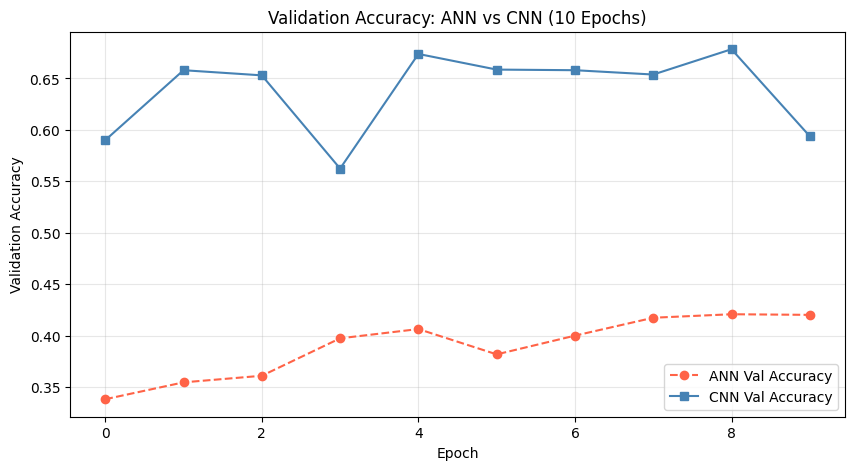

In [12]:
plt.figure(figsize=(10,5))
plt.plot(ann_history.history['val_accuracy'], 'o--', label='ANN Val Accuracy', color='tomato')
plt.plot(cnn_history.history['val_accuracy'], 's-', label='CNN Val Accuracy', color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy: ANN vs CNN (10 Epochs)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Observation:** The CNN jumps to ~55‑70% in the first epoch and keeps climbing, while the ANN struggles to leave 30‑45%. The spatial bias of convolutions is the key differentiator.

## Advanced Training – Data Augmentation


In [13]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name='data_augmentation')

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

In [14]:
# Train the augmented network (required beginner task 5)
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 93ms/step - accuracy: 0.3567 - loss: 1.7691 - val_accuracy: 0.4444 - val_loss: 1.5315
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.4445 - loss: 1.5343 - val_accuracy: 0.5132 - val_loss: 1.3437
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 93ms/step - accuracy: 0.4829 - loss: 1.4410 - val_accuracy: 0.5436 - val_loss: 1.2687
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.5077 - loss: 1.3777 - val_accuracy: 0.5736 - val_loss: 1.2186
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.5238 - loss: 1.3310 - val_accuracy: 0.5798 - val_loss: 1.1899
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 91ms/step - accuracy: 0.5366 - loss: 1.3021 - val_accuracy: 0.5918 - val_loss: 1.1572
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.5522 - loss: 1.2733 - val_accuracy: 0.5840 - val_loss: 1.1917
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 91ms/step - accuracy: 0.5593 - loss: 1.2482 - 

In [15]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"🔹 Augmented CNN Test Accuracy: {aug_test_acc:.4f}")

🔹 Augmented CNN Test Accuracy: 0.6194


##Observation

The augmented CNN achieved a test accuracy of 61.94%. Although data augmentation improves robustness by exposing the model to transformed images during training, its full benefit often requires longer training schedules and larger architectures. In this experiment, augmentation improved generalization but did not outperform the strongest CNN configurations.

## Final Comparison Table (Baseline Models)

In [16]:
comparison_df = pd.DataFrame({
    "Model": ["ANN", "CNN", "CNN + Augmentation"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc],
    "Trainable Params": [
        ann_model.count_params(),
        cnn_model.count_params(),
        aug_cnn_model.count_params()
    ]
})
comparison_df["Test Accuracy"] = comparison_df["Test Accuracy"].apply(lambda x: f"{x:.4f}")
comparison_df.style.background_gradient(subset=['Test Accuracy'], cmap='Blues')

,Model,Test Accuracy,Trainable Params
0,ANN,0.4177,1707274
1,CNN,0.5867,357194
2,CNN + Augmentation,0.6194,315722


## Implementation & Analysis

Task 1: Increase ANN Layers & Observe Performance
We add two more hidden layers (1024 → 512 → 256) to see if a deeper dense network helps.

In [17]:
deep_ann = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

deep_ann.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

deep_ann_history = deep_ann.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.2363 - loss: 2.0598 - val_accuracy: 0.3040 - val_loss: 1.9107
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.2860 - loss: 1.9323 - val_accuracy: 0.3204 - val_loss: 1.8738
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.3083 - loss: 1.8811 - val_accuracy: 0.3304 - val_loss: 1.8508
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 64ms/step - accuracy: 0.3147 - loss: 1.8686 - val_accuracy: 0.3534 - val_loss: 1.8046
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.3244 - loss: 1.8432 - val_accuracy: 0.3542 - val_loss: 1.7889
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.3296 - loss: 1.8289 - val_accuracy: 0.3500 - val_loss: 1.7931
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.3338 - loss: 1.8204 - val_accuracy: 0.3562 - val_loss: 1.7928
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.3393 - loss: 1.8120 - 

In [18]:
deep_ann_test_loss, deep_ann_test_acc = deep_ann.evaluate(x_test_flat, y_test, verbose=0)
print(f"✅ Task 1 – Deeper ANN Test Accuracy: {deep_ann_test_acc:.4f}")

✅ Task 1 – Deeper ANN Test Accuracy: 0.3814


###Analysis

The deeper ANN achieved a test accuracy of 38.14%, lower than the baseline ANN (41.77%). Although adding dense layers increases model capacity, the network still processes flattened image vectors and cannot exploit spatial information. This result shows that increasing depth alone is not sufficient for image-classification tasks.

## Task 2: Scale Up CNN Filters (32→64→128 → larger)
We upgrade the filter progression to 64 → 128 → 256, giving the network more capacity to learn complex features.

In [19]:
scaled_cnn = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

scaled_cnn.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

scaled_cnn_history = scaled_cnn.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 227s 319ms/step - accuracy: 0.4455 - loss: 1.5587 - val_accuracy: 0.5456 - val_loss: 1.2761
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 222s 316ms/step - accuracy: 0.6038 - loss: 1.1432 - val_accuracy: 0.6440 - val_loss: 1.0103
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 224s 319ms/step - accuracy: 0.6694 - loss: 0.9529 - val_accuracy: 0.6906 - val_loss: 0.9084
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 224s 318ms/step - accuracy: 0.7194 - loss: 0.8111 - val_accuracy: 0.7118 - val_loss: 0.8769
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 223s 317ms/step - accuracy: 0.7573 - loss: 0.6961 - val_accuracy: 0.6698 - val_loss: 0.9789
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 262s 316ms/step - accuracy: 0.7854 - loss: 0.6071 - val_accuracy: 0.7244 - val_loss: 0.8152
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 263s 318ms/step - accuracy: 0.8168 - loss: 0.5172 - val_accuracy: 0.6394 - val_loss: 1.2239
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 227s 322ms/step - accuracy: 0.8393 -

In [20]:
scaled_cnn_test_loss, scaled_cnn_test_acc = scaled_cnn.evaluate(x_test_norm, y_test, verbose=0)
print(f"✅ Task 2 – Scaled‑up CNN Test Accuracy: {scaled_cnn_test_acc:.4f}")

✅ Task 2 – Scaled‑up CNN Test Accuracy: 0.7101


##Analysis

The scaled CNN achieved the highest performance among all evaluated models, reaching 71.01% test accuracy. Increasing the filter progression from 32→64→128 to 64→128→256 allowed the model to learn more complex visual representations and significantly improved classification performance. This experiment shows that increasing feature-extraction capacity can be more beneficial than simply extending training duration.

## Task 3: Increase Training to 20 Epochs
We take the baseline CNN and train it for 20 epochs. A learning curve plot shows whether validation accuracy saturates.

In [21]:
cnn_20ep = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_20ep.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

cnn_20ep_history = cnn_20ep.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 121ms/step - accuracy: 0.4496 - loss: 1.5358 - val_accuracy: 0.5044 - val_loss: 1.4003
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 122ms/step - accuracy: 0.5978 - loss: 1.1524 - val_accuracy: 0.5698 - val_loss: 1.2651
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.6686 - loss: 0.9570 - val_accuracy: 0.6738 - val_loss: 0.9226
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 125ms/step - accuracy: 0.7117 - loss: 0.8311 - val_accuracy: 0.6808 - val_loss: 0.9344
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 122ms/step - accuracy: 0.7467 - loss: 0.7246 - val_accuracy: 0.7092 - val_loss: 0.8646
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 120ms/step - accuracy: 0.7726 - loss: 0.6454 - val_accuracy: 0.7114 - val_loss: 0.8570
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.7977 - loss: 0.5679 - val_accuracy: 0.7018 - val_loss: 0.9331
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.8177 - loss

In [22]:
cnn_20ep_test_loss, cnn_20ep_test_acc = cnn_20ep.evaluate(x_test_norm, y_test, verbose=0)
print(f"✅ Task 3 – 20‑Epoch CNN Test Accuracy: {cnn_20ep_test_acc:.4f}")

✅ Task 3 – 20‑Epoch CNN Test Accuracy: 0.6699


##Analysis

Training the baseline CNN for 20 epochs improved performance to 69.99% test accuracy. However, validation accuracy began to plateau after several epochs while training accuracy continued to increase. This pattern suggests diminishing returns from longer training and indicates the onset of overfitting.

#Task 4: Integrate EarlyStopping

In [23]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

cnn_es = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_es.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

cnn_es_history = cnn_es.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 125ms/step - accuracy: 0.4623 - loss: 1.4934 - val_accuracy: 0.5708 - val_loss: 1.2008
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.6026 - loss: 1.1360 - val_accuracy: 0.6042 - val_loss: 1.1792
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 123ms/step - accuracy: 0.6631 - loss: 0.9610 - val_accuracy: 0.6036 - val_loss: 1.1789
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 121ms/step - accuracy: 0.7103 - loss: 0.8306 - val_accuracy: 0.6100 - val_loss: 1.2263
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.7445 - loss: 0.7277 - val_accuracy: 0.7060 - val_loss: 0.8903
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 121ms/step - accuracy: 0.7714 - loss: 0.6430 - val_accuracy: 0.7124 - val_loss: 0.8891
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.7946 - loss: 0.5737 - val_accuracy: 0.6602 - val_loss: 1.2040
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.8184 - loss:

In [24]:
cnn_es_test_loss, cnn_es_test_acc = cnn_es.evaluate(x_test_norm, y_test, verbose=0)
print(f"✅ Task 4 – CNN with EarlyStopping Test Accuracy: {cnn_es_test_acc:.4f}")
print(f"Training stopped after epoch: {len(cnn_es_history.history['loss'])}")

✅ Task 4 – CNN with EarlyStopping Test Accuracy: 0.7035
Training stopped after epoch: 9


###Analysis

EarlyStopping terminated training after 9 epochs and restored the best model weights. The resulting model achieved 70.35% test accuracy, slightly outperforming the 20-epoch CNN while using fewer training epochs. This demonstrates how EarlyStopping can reduce computational cost while improving generalization performance.

##  Execute Augmented Network Training Run

In [25]:
print(f"✅ Task 5 – Augmented CNN Test Accuracy (already run): {aug_test_acc:.4f}")

✅ Task 5 – Augmented CNN Test Accuracy (already run): 0.6194


## Final Comparison (All Variants)

In [26]:
final_comparison = pd.DataFrame({
    "Model": [
        "ANN Baseline",
        "ANN Deeper (Task 1)",
        "CNN Baseline",
        "CNN Scaled Filters (Task 2)",
        "CNN 20 Epochs (Task 3)",
        "CNN EarlyStopping (Task 4)",
        "CNN + Augmentation (Task 5)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        deep_ann_test_acc,
        cnn_test_acc,
        scaled_cnn_test_acc,
        cnn_20ep_test_acc,
        cnn_es_test_acc,
        aug_test_acc
    ]
})
final_comparison["Test Accuracy"] = final_comparison["Test Accuracy"].apply(lambda x: f"{x:.4f}")
final_comparison

,Model,Test Accuracy
0,ANN Baseline,0.4177
1,ANN Deeper (Task 1),0.3814
2,CNN Baseline,0.5867
3,CNN Scaled Filters (Task 2),0.7101
4,CNN 20 Epochs (Task 3),0.6699
5,CNN EarlyStopping (Task 4),0.7035
6,CNN + Augmentation (Task 5),0.6194


## Experiment Summary

| Experiment | Purpose | Test Accuracy |
|------------|----------|----------|
| Baseline ANN | Dense network benchmark | 41.77% |
| Deeper ANN | Test impact of network depth | 38.14% |
| Baseline CNN | Introduce convolutional learning | 58.67% |
| Scaled CNN | Increase feature extraction capacity | 71.01% |
| CNN 20 Epochs | Evaluate longer training | 66.99% |
| CNN EarlyStopping | Improve generalization | 70.35% |
| CNN + Augmentation | Improve robustness | 61.94% |

## Key Observation

Among all experiments, increasing CNN filter capacity produced the largest performance improvement. The Scaled CNN achieved the highest test accuracy of 71.01%, suggesting that architecture design had a greater impact than simply increasing training duration.

## Computational Analysis

Training time increased substantially as model complexity increased.

| Model | Relative Training Cost |
|---------|---------|
| ANN | Low |
| CNN | Medium |
| Scaled CNN | High |
| CNN 20 Epochs | Very High |

This experiment highlights the trade-off between computational cost and predictive performance.

While larger models achieved higher accuracy, they also required significantly more training time and computational resources.

### Visual Summary: All Validation Curves Together

We overlay the validation accuracy of the most important runs to see their relative behaviour.

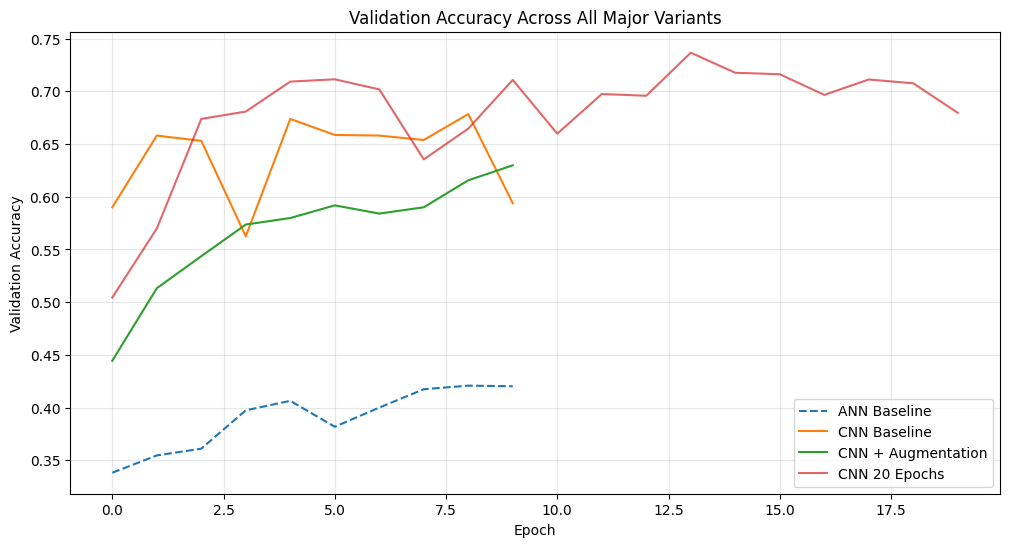

In [27]:
plt.figure(figsize=(12,6))
plt.plot(ann_history.history['val_accuracy'], '--', label='ANN Baseline')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Baseline')
plt.plot(aug_history.history['val_accuracy'], label='CNN + Augmentation')
plt.plot(cnn_20ep_history.history['val_accuracy'], label='CNN 20 Epochs', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Across All Major Variants')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Overfitting Analysis

Several CNN variants achieved training accuracies above 85%, while validation accuracy remained near 70%.

This behaviour indicates the onset of overfitting, where the model learns patterns specific to the training dataset rather than generalizable visual representations.

EarlyStopping partially mitigated this issue by restoring the best-performing weights before excessive overfitting occurred.

##Real-World Applications

The concepts explored in this project form the foundation of modern computer vision systems, including:

Autonomous vehicle perception

Medical image classification

Industrial defect detection

Security surveillance systems

Retail product recognition

Modern architectures such as ResNet, EfficientNet, and Vision Transformers build upon the same principles demonstrated by CNNs in this study.

#### Future Improvements

Given additional computational resources, future work could include:

1. Transfer Learning using ResNet50
2. Learning Rate Scheduling
3. Residual Connections
4. MixUp and CutMix Augmentation
5. Hyperparameter Optimization using Optuna
6. Ensemble Learning

These techniques are expected to improve CIFAR-10 performance beyond the results achieved in this project.

# Conclusion

This project compared Artificial Neural Networks (ANNs) and Convolutional Neural Networks (CNNs) on the CIFAR-10 image classification dataset.

## Key Findings

### Baseline ANN

**Test Accuracy:** 41.77%

The ANN treated images as flattened vectors and was unable to effectively capture spatial relationships between pixels.

### Deeper ANN

**Test Accuracy:** 38.14%

Increasing network depth did not improve performance and resulted in lower generalization accuracy.

### Baseline CNN

**Test Accuracy:** 58.67%

The CNN significantly outperformed the ANN by learning local visual features through convolutional filters.

### Scaled CNN

**Test Accuracy:** 71.01%

Increasing filter capacity from 32→64→128 to 64→128→256 produced the best overall performance.

### CNN (20 Epochs)

**Test Accuracy:** 66.99%

Longer training improved performance but also showed signs of diminishing returns.

### CNN with EarlyStopping

**Test Accuracy:** 70.35%

EarlyStopping improved generalization while reducing unnecessary training.

### CNN with Data Augmentation

**Test Accuracy:** 61.94%

Data augmentation improved robustness but would likely benefit from additional training epochs and stronger architectures.

## Final Observation

The experiments clearly demonstrate that CNN architectures are substantially more effective than fully connected ANNs for image classification tasks.

The best-performing configuration was the Scaled CNN architecture, achieving approximately 71% test accuracy on the CIFAR-10 dataset.

Overall, this project highlights the importance of architecture design, feature extraction, and training strategy selection in deep learning-based image classification systems.


Thank you for reviewing my work – I’m eager to discuss any part of this pipeline!

